In [2]:
import os
import kagglehub
import shutil
import pandas as pd
import numpy as np
import sys
import importlib



In [ ]:
!pip install pandas_ta

In [4]:
import pandas_ta as ta

In [5]:
from google.colab import drive


drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/Proiect_Licenta_XAUUSD'

folders = ['data/raw', 'data/processed', 'models', 'notebooks', 'src']
for folder in folders:
    os.makedirs(os.path.join(PROJECT_PATH, folder), exist_ok=True)

print("Project structure has been succesfully created!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project structure has been succesfully created!


In [ ]:


# path = kagglehub.dataset_download("novandraanugrah/xauusd-gold-price-historical-data-2004-2024")
# 
# print("Path to dataset files:", path)

# /content/drive/MyDrive/Proiect_Licenta_XAUUSD/data/raw/gold_1h_2004_2024.csv


In [ ]:


# source_file = os.path.join(path, os.listdir(path)[0]) 
# destination_file = os.path.join(PROJECT_PATH, 'data/raw/gold_1h_2004_2024.csv')
# 
# shutil.copy(source_file, destination_file)
# print(f" The file has been permanently saved to: {destination_file}")



In [6]:


file_path = '/content/drive/MyDrive/Proiect_Licenta_XAUUSD/data/raw/gold_1h_2004_2024.csv'

df = pd.read_csv(file_path, sep=';')

print("Identified columns:", df.columns.tolist())
print("\n First 5 rows ")
display(df.head())

Identified columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

 First 5 rows 


,Date,Open,High,Low,Close,Volume
0,2004.06.11 07:15,384.0,384.1,384.0,384.0,3
1,2004.06.11 07:20,384.1,384.1,383.8,383.8,3
2,2004.06.11 07:25,383.8,384.3,383.8,384.3,6
3,2004.06.11 07:30,383.8,383.8,383.8,383.8,2
4,2004.06.11 07:35,383.8,384.3,383.6,383.8,6


In [10]:
def preprocess_initial_data(df):
    # Columns name standardization
    df.columns = [col.lower().strip() for col in df.columns]

    # Time column
    potential_time_cols = ['time', 'date', 'timestamp', 'gmt time']
    time_col = next((c for c in potential_time_cols if c in df.columns), None)
    
    if time_col is None:
        raise ValueError(f"The time column was not found. Available columns: {df.columns.tolist()}")

    # Conversion to datetime
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=time_col)
    df = df.set_index(time_col)

    # RESAMPLING to 1H 
    resample_logic = {
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }
    
    df = df.resample('h').apply(resample_logic)

    # Cleaning after resampling
    df = df.dropna(subset=['open'])

    return df

df_cleaned = preprocess_initial_data(df)
print(f"Data after resampling to 1H: {df_cleaned.shape[0]} rows.")
display(df_cleaned.head(10))

Data after resampling to 1H: 124887 rows.


,open,high,low,close,volume
date,,,,,
2004-06-11 07:00:00,384.0,384.3,383.3,383.8,44
2004-06-11 08:00:00,383.8,384.3,383.1,383.1,41
2004-06-11 09:00:00,383.1,384.1,382.8,383.1,55
2004-06-11 10:00:00,383.0,383.8,383.0,383.6,33
2004-06-11 11:00:00,383.6,383.8,383.5,383.6,23
2004-06-11 12:00:00,383.5,384.1,383.3,383.3,20
2004-06-11 13:00:00,383.6,384.3,383.6,384.0,15
2004-06-11 14:00:00,383.8,383.8,383.8,383.8,4
2004-06-11 15:00:00,383.8,384.6,383.8,384.6,9


In [7]:

# processed_data_path = os.path.join(PROJECT_PATH, 'data/processed/gold_1h_clean.csv')
# 
# # Save the dataframe
# df_cleaned.to_csv(processed_data_path, index=True)
# 
# print(f"Success! The hourly cleaned dataset has been saved to: {processed_data_path}")
# print(f"Total rows: {len(df_cleaned)}")



In [11]:


def add_manual_features(df):
    
    df = df.copy()

    df['log_return'] = np.log(df['close'] / df['close'].shift(1))

    
    df['sma_20'] = df['close'].rolling(window=20).mean()
    df['sma_50'] = df['close'].rolling(window=50).mean()

    #Volatility: Rolling standard deviation of log returns
    df['volatility_20'] = df['log_return'].rolling(window=20).std()

    # RSI (Relative Strength Index)
    window_rsi = 14
    delta = df['close'].diff()
    
    gain = (delta.where(delta > 0, 0)).rolling(window=window_rsi).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window_rsi).mean()
    
    rs = gain / loss
    df['rsi_14'] = 100 - (100 / (1 + rs))

    df = df.dropna()

    return df


df_features = add_manual_features(df_cleaned)

display(df_features[['close', 'sma_20', 'sma_50', 'volatility_20', 'rsi_14']].head())


,close,sma_20,sma_50,volatility_20,rsi_14
date,,,,,
2004-06-15 15:00:00,385.3,382.705,383.076,0.001602,65.432099
2004-06-15 16:00:00,385.1,382.795,383.102,0.001610,61.538462
2004-06-15 17:00:00,388.3,383.070,383.206,0.002373,78.431373
2004-06-15 18:00:00,387.6,383.310,383.296,0.002435,73.148148
2004-06-15 19:00:00,387.1,383.535,383.366,0.002460,73.148148


In [12]:

indicators_code = '''
import pandas_ta as ta
import numpy as np
import pandas as pd

def add_trading_strategy_indicators(df):
    df = df.copy()

    # TREND INDICATORS (EMA)
    df['ema_50'] = ta.ema(df['close'], length=50)
    df['ema_200'] = ta.ema(df['close'], length=200)
    df['dist_ema_200'] = (df['close'] - df['ema_200']) / df['ema_200']

    # VOLATILITY & RISK (ATR & BOLLINGER)
    df['atr'] = ta.atr(df['high'], df['low'], df['close'], length=14)
    bb_data = ta.bbands(df['close'], length=20, std=2)
    df['bb_lower'] = bb_data.iloc[:, 0]
    df['bb_upper'] = bb_data.iloc[:, 2]
    df['bb_pct'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

    # WILLIAMS FIX VIX 
    lookback_vix = 22
    df['highest_close'] = df['close'].rolling(window=lookback_vix).max()
    df['fix_vix'] = ((df['highest_close'] - df['low']) / df['highest_close']) * 100
    vix_bb_length = 20
    vix_bb_std = 2.0
    df['vix_basis'] = df['fix_vix'].rolling(window=vix_bb_length).mean()
    df['vix_upper_band'] = df['vix_basis'] + (vix_bb_std * df['fix_vix'].rolling(window=vix_bb_length).std())
    df['is_vix_green'] = (df['fix_vix'] >= df['vix_upper_band']).astype(int)

    #  SMI ERGODIC 
    smi_data = ta.smi(df['close'], fast=10, slow=20, signal=5)
    df = pd.concat([df, smi_data], axis=1)
    df.columns = [col.lower().replace('.', '_') for col in df.columns]

    
    smi_cols = [c for c in df.columns if 'smi' in c and '_s_' not in c and 'oversold' not in c]
    if smi_cols:
        target_smi = smi_cols[0]
        df['smi_oversold'] = (df[target_smi] <= -0.5).astype(int)
        df['smi_overbought'] = (df[target_smi] >= 0.5).astype(int)
    else:
        df['smi_oversold'] = 0
        df['smi_overbought'] = 0

    # RETURNS & TIME
    df['ret_1h'] = np.log(df['close'] / df['close'].shift(1))
    df['ret_3h'] = np.log(df['close'] / df['close'].shift(3))
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek

    # Cleanup
    cols_to_drop = ['highest_close', 'vix_basis', 'vix_upper_band']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    return df.dropna()
'''

with open(f"{PROJECT_PATH}/src/indicators.py", 'w') as f:
    f.write(indicators_code)



In [13]:

path_to_add = f"{PROJECT_PATH}/src"
if path_to_add not in sys.path:
    sys.path.append(path_to_add)


import indicators as ind
importlib.reload(ind)


df_final = ind.add_trading_strategy_indicators(df_cleaned)

print(f"We have {len(df_final)} rows and {df_final.shape[1]} columns.")
display(df_final[['close', 'is_vix_green', 'smi_oversold']].tail())

We have 124688 rows and 23 columns.


,close,is_vix_green,smi_oversold
date,,,
2025-12-31 19:00:00,4321.95,0,0
2025-12-31 20:00:00,4319.57,0,0
2025-12-31 21:00:00,4311.32,0,0
2025-12-31 22:00:00,4313.33,0,0
2025-12-31 23:00:00,4318.36,0,0


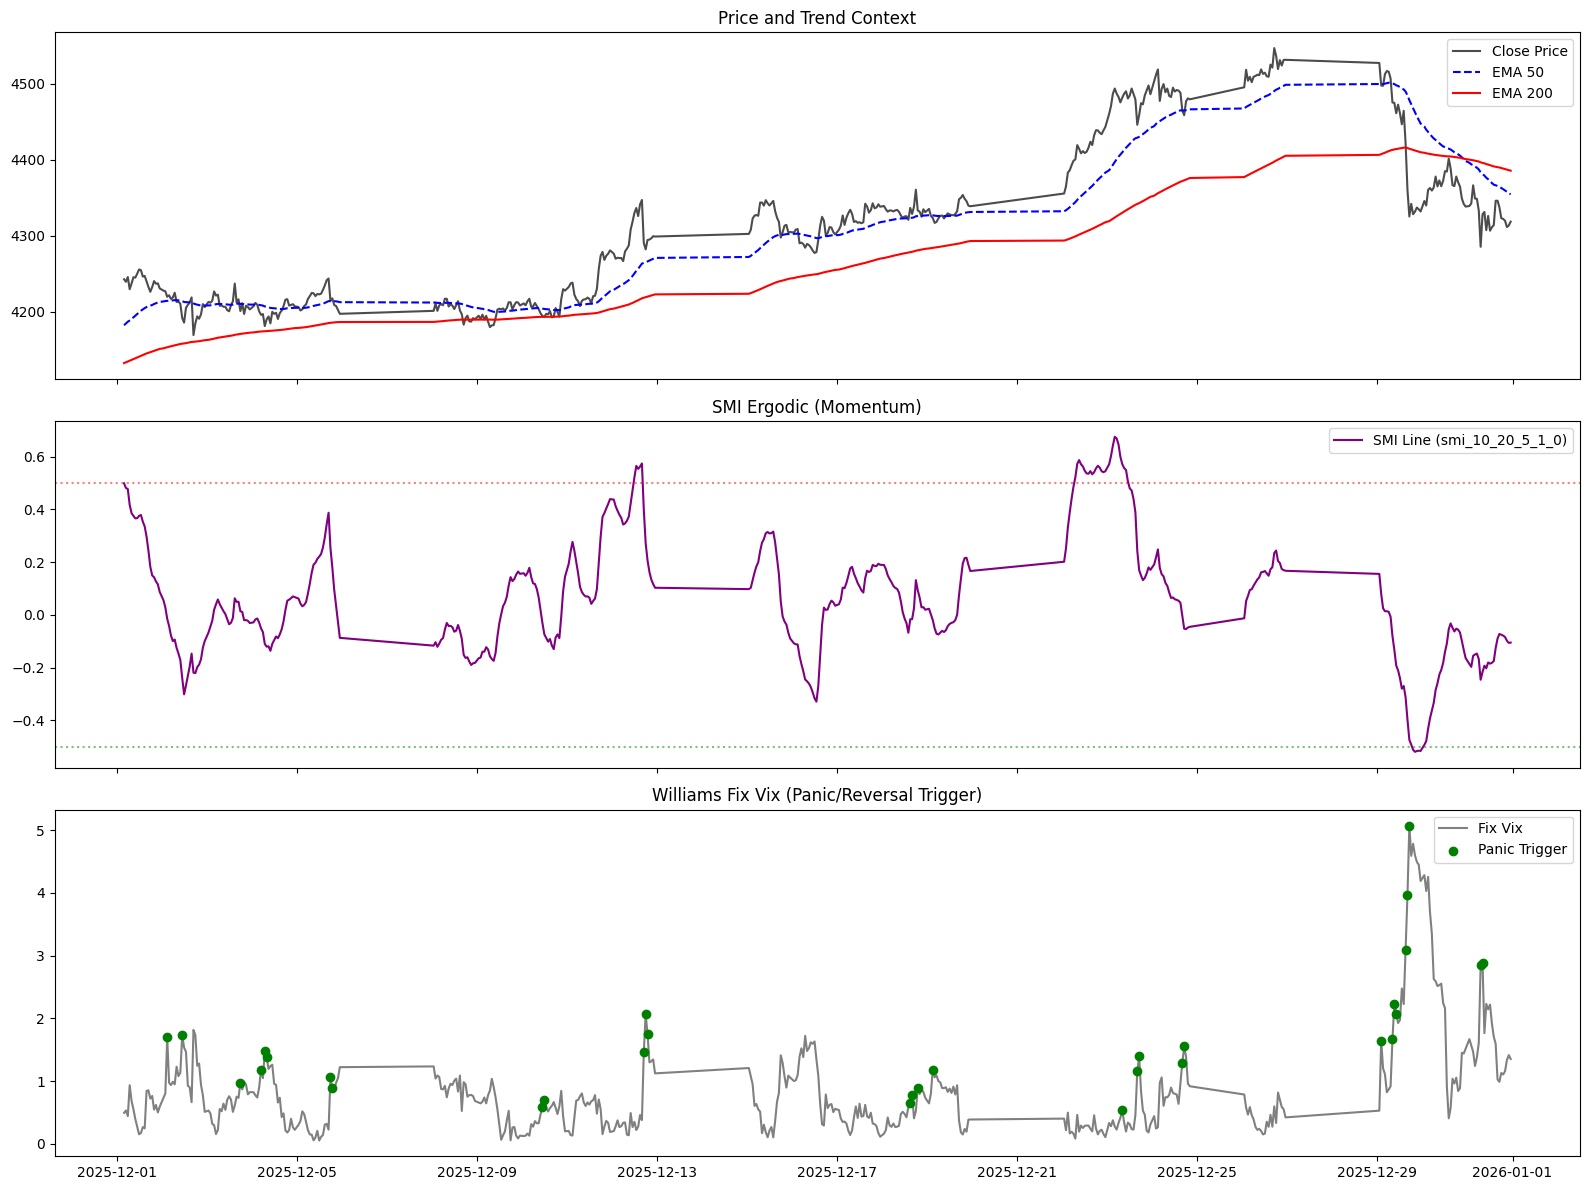

In [14]:
import matplotlib.pyplot as plt

sample_df = df_final.tail(500)

smi_line_cols = [c for c in sample_df.columns if 'smi' in c and 'over' not in c and '_s' not in c]
smi_signal_cols = [c for c in sample_df.columns if 'smi' in c and 'over' not in c and '_s' in c]

smi_line = smi_line_cols[0] if smi_line_cols else None
smi_signal = smi_signal_cols[0] if smi_signal_cols else None

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Price and EMAs 
ax1.plot(sample_df['close'], label='Close Price', color='black', alpha=0.7)
if 'ema_50' in sample_df.columns:
    ax1.plot(sample_df['ema_50'], label='EMA 50', color='blue', linestyle='--')
if 'ema_200' in sample_df.columns:
    ax1.plot(sample_df['ema_200'], label='EMA 200', color='red')
ax1.set_title('Price and Trend Context')
ax1.legend()

# SMI Ergodic 
if smi_line:
    ax2.plot(sample_df[smi_line], label=f'SMI Line ({smi_line})', color='purple')
if smi_signal:
    ax2.plot(sample_df[smi_signal], label=f'Signal Line ({smi_signal})', color='orange', alpha=0.5)

ax2.axhline(0.5, color='red', linestyle=':', alpha=0.5)   # Overbought
ax2.axhline(-0.5, color='green', linestyle=':', alpha=0.5) # Oversold
ax2.set_title('SMI Ergodic (Momentum)')
ax2.legend()

# Williams Fix Vix 
if 'fix_vix' in sample_df.columns:
    ax3.plot(sample_df['fix_vix'], label='Fix Vix', color='grey')
    if 'is_vix_green' in sample_df.columns:
        green_bars = sample_df[sample_df['is_vix_green'] == 1]
        ax3.scatter(green_bars.index, green_bars['fix_vix'], color='green', label='Panic Trigger', zorder=5)
ax3.set_title('Williams Fix Vix (Panic/Reversal Trigger)')
ax3.legend()

plt.tight_layout()
plt.show()

In [12]:
# processed_path = os.path.join(PROJECT_PATH, 'data/processed/XAUUSD_with_indicators.csv')
# df_final.to_csv(processed_path)
# print(f"Processed data has been saved in: {processed_path}")